# 38 — Image localization and bounding boxes

Image classification answers **what** is present. Localization additionally answers **where** one object is, while object detection may predict multiple objects, classes, and boxes.

This notebook builds the geometry needed by later detection topics. We will:

- distinguish classification, localization, and detection;
- work with corner, top-left/size, and center/size box formats;
- convert and clip boxes safely;
- draw boxes on an image;
- derive intersection over union (IoU);
- calculate pairwise IoU matrices.

We use synthetic images so every coordinate is known exactly. The completed, validated counterparts of these educational functions are available in `cs231n_practice/detection.py`; the implementations remain here so their geometry stays visible.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

np.set_printoptions(precision=3, suppress=True)

## 1. Classification, localization, and detection

These tasks predict increasingly structured outputs:

| Task | Typical output | Number of objects |
| --- | --- | --- |
| Classification | one vector of class scores | usually one dominant label |
| Classification + localization | class scores and one box | usually one object |
| Object detection | a variable-size collection of boxes, labels, and scores | zero or more objects |

A bounding box is an axis-aligned rectangle. It is simpler than an object mask: background pixels and pixels from other objects may still lie inside it.

### Exercise 1 — Identify the task

Assign `"classification"`, `"localization"`, or `"detection"` to each output description.

In [2]:
task_by_output = {
    "ten class scores": "classification",
    "one class and one box": "localization",
    "an unknown number of scored class-box predictions": "detection",
}

assert task_by_output == {
    "ten class scores": "classification",
    "one class and one box": "localization",
    "an unknown number of scored class-box predictions": "detection",
}

## 2. Coordinate convention and box formats

Image arrays have shape `(height, width, channels)`, but box coordinates are conventionally written in **x, y order**:

- $x$ is horizontal and increases from left to right;
- $y$ is vertical and increases from top to bottom.

We use continuous, half-open image coordinates. A valid corner box is

$$[x_1,y_1,x_2,y_2),$$

where the left/top edges are included and the right/bottom edges are excluded. Its width and height are therefore

$$w=x_2-x_1, \qquad h=y_2-y_1,$$

with no `+1`. For an image of width $W$ and height $H$, valid boundary coordinates range from 0 through $W$ and 0 through $H$.

Three common formats are:

```text
xyxy:  (x1, y1, x2, y2)  corner coordinates
xywh:  (x,  y,  w,  h)   top-left corner plus size
cxcywh:(cx, cy, w,  h)   center plus size
```

The format must always be stated; four numbers alone are ambiguous.

### Exercise 2 — Convert box formats

Implement conversions that accept an array with final dimension 4. Preserve all leading dimensions so the same functions work for one box `(4,)` or many boxes `(..., 4)`.

In [ ]:
def xywh_to_xyxy(boxes):
    """Convert top-left/size boxes to corner boxes."""
    boxes = np.asarray(boxes)
    x, y, width, height = np.moveaxis(boxes, -1, 0)
    # stack x1, y1, x2, y2 along the final axis.
    x1 = x
    y1 = y
    x2 = x + width
    y2 = y + height
    return np.stack([x1, y1, x2, y2], axis=-1)

def cxcywh_to_xyxy(boxes):
    """Convert center/size boxes to corner boxes."""
    boxes = np.asarray(boxes)
    center_x, center_y, width, height = np.moveaxis(boxes, -1, 0)
    # each corner is one half-width/height away from the center.
    x1 = center_x - width / 2
    y1 = center_y - height / 2
    x2 = center_x + width / 2
    y2 = center_y + height / 2
    return np.stack([x1, y1, x2, y2], axis=-1)

def xyxy_to_cxcywh(boxes):
    """Convert corner boxes to center/size boxes."""
    boxes = np.asarray(boxes)
    x1, y1, x2, y2 = np.moveaxis(boxes, -1, 0)
    # calculate center, width, and height and stack them.
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    width = x2 - x1
    height = y2 - y1
    return np.stack([center_x, center_y, width, height], axis=-1)

box_xywh = np.array([2.0, 3.0, 5.0, 4.0])
box_xyxy = xywh_to_xyxy(box_xywh)
np.testing.assert_allclose(box_xyxy, [2.0, 3.0, 7.0, 7.0])
np.testing.assert_allclose(
    xyxy_to_cxcywh(box_xyxy), [4.5, 5.0, 5.0, 4.0]
)
np.testing.assert_allclose(
    cxcywh_to_xyxy(xyxy_to_cxcywh(box_xyxy)), box_xyxy
)

batched_boxes = np.array([[0, 0, 2, 4], [3, 1, 5, 2]], dtype=float)
assert xywh_to_xyxy(batched_boxes).shape == (2, 4)
print("xywh -> xyxy:", box_xywh, "->", box_xyxy)

xywh -> xyxy: [2. 3. 5. 4.] -> [2. 3. 7. 7.]


### Why use `np.moveaxis(boxes, -1, 0)`?

The final axis of a box array contains its four coordinate components. In `np.moveaxis(array, source, destination)`, `-1` means the last axis and `0` means the first axis. Therefore,

```python
np.moveaxis(boxes, -1, 0)
```

temporarily moves the four coordinate components to the front so they can be unpacked by name. For a batch of two `xywh` boxes:

```text
boxes with shape (2, 4):

[[0, 0, 2, 4],
 [3, 1, 5, 2]]

move the last axis to the front -> shape (4, 2):

[[0, 3],    x values
 [0, 1],    y values
 [2, 5],    width values
 [4, 2]]    height values
```

The assignment

```python
x, y, width, height = np.moveaxis(boxes, -1, 0)
```

then gives one array per component. Calculations such as `x + width` operate on every box at once. Finally,

```python
np.stack([x1, y1, x2, y2], axis=-1)
```

places the four newly calculated components back on the final axis.

For a single box with shape `(4,)`, moving its only axis has no visible effect. The same code still works. Unlike `boxes.T`, `moveaxis` also behaves as intended for arrays with additional leading dimensions:

```text
(4,)       -> (4,)
(N, 4)     -> (4, N)
(N, K, 4)  -> (4, N, K)
```

The overall pattern is: **move components to the front, unpack and calculate, then stack components back at the end**.

## 3. Validate and clip boxes

A corner box has positive area only when $x_2>x_1$ and $y_2>y_1$. Coordinates predicted by a model may extend beyond the image, so visualization and evaluation pipelines often clip them to image boundaries.

Clipping and validity are separate operations. Clipping an outside box can collapse it to zero width or height, so validity should be checked afterward.

### Exercise 3 — Clip coordinates and detect valid boxes

In [11]:
def clip_boxes_xyxy(boxes, image_height, image_width):
    """Clip corner boxes to continuous image boundaries."""
    boxes = np.asarray(boxes).copy()
    # clip x coordinates to [0, image_width] and y coordinates
    # to [0, image_height]. Remember which columns contain x and y.
    boxes[:, 0] = np.clip(boxes[:, 0], 0, image_width)
    boxes[:, 1] = np.clip(boxes[:, 1], 0, image_height)
    boxes[:, 2] = np.clip(boxes[:, 2], 0, image_width)
    boxes[:, 3] = np.clip(boxes[:, 3], 0, image_height)
    return boxes

def valid_boxes_xyxy(boxes):
    """Return a Boolean validity value for every box."""
    boxes = np.asarray(boxes)
    # require strictly positive width and height.
    valid_x = boxes[:, 2] > boxes[:, 0]
    valid_y = boxes[:, 3] > boxes[:, 1]
    valid = valid_x & valid_y
    return valid

outside_boxes = np.array([
    [-2.0, 2.0, 8.0, 12.0],
    [9.0, 4.0, 15.0, 7.0],
    [-4.0, 1.0, -1.0, 5.0],
])
clipped_boxes = clip_boxes_xyxy(outside_boxes, image_height=10, image_width=12)
np.testing.assert_allclose(clipped_boxes, [
    [0.0, 2.0, 8.0, 10.0],
    [9.0, 4.0, 12.0, 7.0],
    [0.0, 1.0, 0.0, 5.0],
])
np.testing.assert_array_equal(valid_boxes_xyxy(clipped_boxes), [True, True, False])
print(clipped_boxes)

[[ 0.  2.  8. 10.]
 [ 9.  4. 12.  7.]
 [ 0.  1.  0.  5.]]


## 4. Draw boxes and verify coordinates visually

A visual check often catches swapped x/y coordinates, incorrect format assumptions, and off-by-one errors immediately. `Rectangle` expects `(x, y, width, height)`, even when our stored boxes use `xyxy`.

### Exercise 4 — Create a synthetic scene and draw its boxes

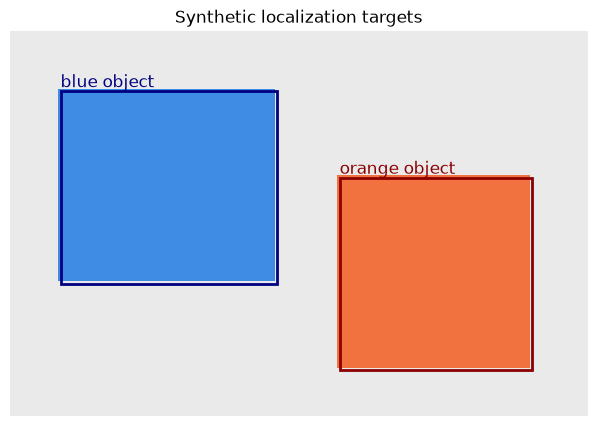

In [15]:
image_height, image_width = 80, 120
image = np.full((image_height, image_width, 3), 0.92)
# Two colored objects whose exact extents are known.
image[12:52, 10:55] = [0.25, 0.55, 0.90]
image[30:70, 68:108] = [0.95, 0.45, 0.25]
ground_truth_boxes = np.array([
    [10.0, 12.0, 55.0, 52.0],
    [68.0, 30.0, 108.0, 70.0],
])
labels = ["blue object", "orange object"]
colors = ["navy", "darkred"]

fig, axis = plt.subplots(figsize=(8, 5))
axis.imshow(image)
for box, label, color in zip(ground_truth_boxes, labels, colors):
    x1, y1, x2, y2 = box
    # create an unfilled Rectangle using top-left position, width,
    # and height; add it to axis and place its label near the top-left.
    rectangle = Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=2)
    axis.add_patch(rectangle)
    axis.text(x1, y1, label, fontsize=12, color=color, verticalalignment="bottom")
axis.set_title("Synthetic localization targets")
axis.axis("off")
plt.show()

## 5. Intersection over Union

IoU measures the overlap between two spatial regions. For boxes $A$ and $B$,

$$\mathrm{IoU}(A,B)=\frac{|A\cap B|}{|A\cup B|}.$$

The intersection boundaries are

$$x_1^I=\max(x_1^A,x_1^B), \quad y_1^I=\max(y_1^A,y_1^B),$$

$$x_2^I=\min(x_2^A,x_2^B), \quad y_2^I=\min(y_2^A,y_2^B).$$

If the boxes do not overlap, an intersection width or height becomes negative. Clamp both to zero before multiplying. The union area is

$$|A\cup B|=|A|+|B|-|A\cap B|.$$

The subtraction prevents the intersection from being counted twice. IoU is 1 for identical positive-area boxes and 0 for boxes with no positive-area overlap. Touching edges have IoU 0 under our continuous convention.

### Exercise 5 — Implement IoU for aligned box pairs

`box_iou_aligned(a, b)` compares corresponding boxes. NumPy broadcasting may supply shared leading dimensions, but it does not construct every possible pair yet.

In [54]:
# ... means “preserve every leading dimension and index only the final component axis.”
test_arr = np.random.rand(3, 4, 5, 6)
(
    test_arr.shape,
    test_arr[...].shape,
    test_arr[..., 0].shape,
    test_arr[..., 0, 0].shape,
    test_arr[0, ...].shape,
    test_arr[0, 0, ...].shape,
    test_arr[0, 0, :, :].shape,
    test_arr[0, ..., 0].shape,
    test_arr[0, :, :, 0].shape,
)


((3, 4, 5, 6),
 (3, 4, 5, 6),
 (3, 4, 5),
 (3, 4),
 (4, 5, 6),
 (5, 6),
 (5, 6),
 (4, 5),
 (4, 5))

In [59]:
def box_area_xyxy(boxes):
    """Return nonnegative areas of corner-format boxes."""
    boxes = np.asarray(boxes)
    # clamp width and height at zero, then multiply them.
    width = np.maximum(boxes[..., 2] - boxes[..., 0], 0)
    height = np.maximum(boxes[..., 3] - boxes[..., 1], 0)
    return width * height

def box_iou_aligned(boxes_a, boxes_b):
    """Return IoU between corresponding, broadcastable box pairs."""
    boxes_a = np.asarray(boxes_a)
    # print("boxes_a shape:", boxes_a.shape)
    boxes_b = np.asarray(boxes_b)
    # print("boxes_b shape:", boxes_b.shape)
    # compute intersection top-left and bottom-right coordinates.
    intersection_top_left = np.maximum(
        boxes_a[..., :2],
        boxes_b[..., :2],
    )
    # print("intersection_top_left shape:", intersection_top_left.shape)
    intersection_bottom_right = np.minimum(
        boxes_a[..., 2:],
        boxes_b[..., 2:],
    )
    # print("intersection_bottom_right shape:", intersection_bottom_right.shape)
    intersection_boxes = np.concatenate(
        [intersection_top_left, intersection_bottom_right], axis=-1
    )
    intersection_area = box_area_xyxy(intersection_boxes)
    # print("intersection_area shape:", intersection_area.shape)
    # calculate union and safely divide intersection by union.
    area_a = box_area_xyxy(boxes_a)
    area_b = box_area_xyxy(boxes_b)
    union_area = area_a + area_b - intersection_area
    # print("union_area shape:", union_area.shape)

    return np.divide(
        intersection_area,
        union_area,
        out=np.zeros_like(union_area, dtype=float),
        where=union_area > 0,
    )

reference = np.array([0.0, 0.0, 4.0, 4.0])
comparison_boxes = np.array([
    [0.0, 0.0, 4.0, 4.0],  # identical
    [2.0, 0.0, 6.0, 4.0],  # half-width overlap
    [4.0, 0.0, 8.0, 4.0],  # touching edge only
    [5.0, 5.0, 7.0, 7.0],  # disjoint
])
ious = box_iou_aligned(reference, comparison_boxes)
np.testing.assert_allclose(ious, [1.0, 1.0 / 3.0, 0.0, 0.0])
np.testing.assert_allclose(
    box_iou_aligned(reference, comparison_boxes),
    box_iou_aligned(comparison_boxes, reference),
)
print("IoUs:", ious)

IoUs: [1.    0.333 0.    0.   ]


### Can both inputs contain multiple boxes?

Yes. `box_iou_aligned` accepts multiple boxes in either input, but NumPy broadcasting determines which boxes are compared. It does not automatically construct every possible pair.

#### One box against many boxes

```text
boxes_a: (4,)
boxes_b: (M, 4)
result:  (M,)
```

The single box is broadcast across all $M$ boxes. Keeping the single box as `(1, 4)` has the same one-to-many effect because its leading dimension can expand from 1 to $M$.

```python
one_reference = np.array([[0, 0, 4, 4]])     # (1, 4)
many_boxes = np.array([                      # (3, 4)
    [0, 0, 4, 4],
    [2, 0, 6, 4],
    [5, 5, 7, 7],
])
box_iou_aligned(one_reference, many_boxes)   # shape (3,)
```

#### Multiple aligned pairs

```text
boxes_a: (M, 4)
boxes_b: (M, 4)
result:  (M,)
```

Equal-sized inputs are compared row by row: `boxes_a[0]` with `boxes_b[0]`, `boxes_a[1]` with `boxes_b[1]`, and so on. For example:

```python
references = np.array([
    [0, 0, 4, 4],
    [2, 2, 6, 6],
])
comparisons = np.array([
    [1, 0, 5, 4],
    [2, 2, 6, 6],
])
aligned_ious = box_iou_aligned(references, comparisons)  # shape (2,)
```

This calculates two IoUs, not four. That row-by-row meaning is why the function is called `box_iou_aligned`.

#### Every reference against every comparison

For $R$ references and $M$ comparisons, add separate singleton axes:

```python
references[:, None, :]   # (R, 1, 4)
comparisons[None, :, :]  # (1, M, 4)

all_ious = box_iou_aligned(
    references[:, None, :],
    comparisons[None, :, :],
)
# all_ious has shape (R, M)
```

Broadcasting expands `(R, 1, 4)` and `(1, M, 4)` to compatible `(R, M, 4)` box pairs. The output entry `all_ious[i, j]` is the IoU between reference $i$ and comparison $j$. Exercise 6 packages exactly this operation in `pairwise_box_iou`.

## 6. Pairwise IoU matrices

Detection frequently compares $M$ predictions with $K$ ground-truth boxes. The desired result has shape `(M, K)`, where entry `[i, j]` is the IoU between prediction $i$ and target $j$.

We can create the pair axes without loops:

```text
predicted_boxes[:, None, :]     (M, 1, 4)
target_boxes[None, :, :]        (1, K, 4)
broadcasted IoU result          (M, K)
```

### Exercise 6 — Calculate all prediction-target overlaps

rows: predictions; columns: ground truth
 [[0.813 0.   ]
 [0.    0.79 ]
 [0.216 0.118]]


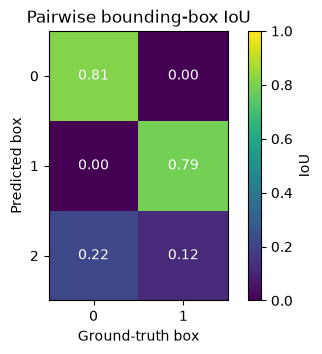

In [60]:
def pairwise_box_iou(boxes_a, boxes_b):
    """Return all pairwise IoUs with shape (len(boxes_a), len(boxes_b))."""
    boxes_a = np.asarray(boxes_a)
    boxes_b = np.asarray(boxes_b)
    # add singleton pair axes and reuse box_iou_aligned.
    boxes_a = boxes_a[:, np.newaxis, :]
    boxes_b = boxes_b[np.newaxis, :, :]
    return box_iou_aligned(boxes_a, boxes_b)

predicted_boxes = np.array([
    [8.0, 10.0, 52.0, 50.0],
    [65.0, 28.0, 110.0, 73.0],
    [35.0, 20.0, 80.0, 60.0],
])
pairwise_ious = pairwise_box_iou(predicted_boxes, ground_truth_boxes)
assert pairwise_ious.shape == (3, 2)
assert np.argmax(pairwise_ious[0]) == 0
assert np.argmax(pairwise_ious[1]) == 1
assert np.all((0.0 <= pairwise_ious) & (pairwise_ious <= 1.0))
print("rows: predictions; columns: ground truth\n", pairwise_ious)

fig, axis = plt.subplots(figsize=(5, 3.5))
heatmap = axis.imshow(pairwise_ious, cmap="viridis", vmin=0, vmax=1)
axis.set(
    xlabel="Ground-truth box", ylabel="Predicted box",
    xticks=np.arange(2), yticks=np.arange(3),
    title="Pairwise bounding-box IoU",
)
for row in range(pairwise_ious.shape[0]):
    for column in range(pairwise_ious.shape[1]):
        axis.text(column, row, f"{pairwise_ious[row, column]:.2f}",
                  ha="center", va="center", color="white")
fig.colorbar(heatmap, ax=axis, label="IoU")
plt.show()

## 7. Interpret IoU carefully

IoU is scale-invariant under uniform coordinate scaling: doubling every coordinate multiplies both intersection and union areas by four, leaving their ratio unchanged. It is not equally sensitive to every error, however. The same absolute coordinate shift hurts a small object more than a large object because it represents a larger fraction of the small object's extent.

IoU also measures geometric overlap only. A perfectly placed box with the wrong class is still a classification error, and a loose axis-aligned box may include substantial background. Later notebooks will combine IoU with class labels, confidence scores, matching rules, and non-maximum suppression.

## Reflection

Answer briefly in your own words.

1. How does localization differ from classification and object detection?
2. Why must the bounding-box format and coordinate convention be stated explicitly?
3. Why is there no `+1` in the width or area formulas used here?
4. Why should validity be checked after clipping a box?
5. Why is the intersection width or height clamped at zero?
6. Why does the union formula subtract the intersection area?
7. What do the rows and columns of a pairwise IoU matrix represent?
8. Why can the same coordinate error reduce IoU more for a small object than for a large object?
9. What important information does IoU not measure?

### Answers

1. Classification predicts what category is present. Localization usually predicts one object’s class and bounding box. Object detection predicts a variable number of boxes, classes, and usually confidence scores.
2. The same four numbers can mean corner coordinates, top-left plus size, or center plus size. We must also know the x/y order and whether the maximum boundary is inclusive or exclusive; otherwise conversions, areas, visualizations, and metrics can be wrong.
3. There is no +1 because we use continuous, half-open boundary coordinates. x2 is the excluded right boundary, so the interval [x1, x2) has width x2 - x1. The fact that the image begins at (0, 0) is not the reason.
4. Clipping can collapse a box that lies outside the image to zero width or zero height. Such a degenerate box remains invalid and should be rejected or ignored after clipping.
5. to avoid negative distances or areas. When boxes are disjoint, the calculated intersection width or height becomes negative. Negative geometric area is meaningless, so it is clamped to zero to represent no overlap.
6. it is already part of the area A and area B so it should be substacted once
7. Each row represents one predicted box, and each column represents one ground-truth box. Entry [i, j] contains the IoU between prediction i and ground-truth box j.
8. for small object it is bigger portion from total area. The same absolute coordinate error represents a larger fraction of a small object’s width, height, and area, so its relative overlap decreases more sharply.
9. IoU measures only geometric overlap. It does not measure whether the predicted class is correct, how confident the model is, whether the box contains background, or how accurately the object’s exact shape is segmented.